<a href="https://colab.research.google.com/github/Yousuf180/Karachi-aqi-predictor/blob/main/AQI_Forecasting_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:

!pip install hopsworks scikit-learn pandas numpy requests streamlit shap joblib python-dotenv pyngrok -q

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [34]:
# Cell 2: Import everything we need
import os
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")
print(f"Current time: {datetime.now()}")

✅ Libraries imported!
Current time: 2026-06-21 14:49:10.513152


In [35]:
# Cell 3: Enter your API keys (replace with your actual keys)

# Get these from https://c.app.hopsworks.ai
HOPSWORKS_API_KEY = "WtY94d9J55EN71ai.0xi2mLp8dnsUdeK5jE5hQpGTEC45sMDTvfJLUuiZjDx5jXslcpr0bOsORyIZXmPw"  # Paste your Hopsworks key
HOPSWORKS_PROJECT = "Aqi_project_Yousuf"       # Your Hopsworks project name

# Get from https://aqicn.org/data-platform/token/
AQICN_TOKEN = "1f245d5e610135f6ee652dbd11c63413898f7436"  # Your AQICN token

# Get from https://openweathermap.org/api
OPENWEATHER_API_KEY = "39ad7171ca3c5fe096a849af68d494b8"  # Your OpenWeather API key

# Set your city (examples: "Beijing", "London", "Delhi", "Los Angeles")
CITY = "Karachi"

print("✅ API keys configured!")
print(f"📡 Fetching data for: {CITY}")

✅ API keys configured!
📡 Fetching data for: Karachi


In [36]:
# Cell 4: Verify all APIs are working
print("🔍 Testing API connections...\n")

# Test AQICN
try:
    url = f"https://api.waqi.info/feed/{"Karachi"}/?token={"1f245d5e610135f6ee652dbd11c63413898f7436"}"
    response = requests.get(url).json()
    if response['status'] == 'ok':
        print(f"✅ AQICN API: Working! Current AQI = {response['data']['aqi']}")
    else:
        print(f"❌ AQICN API Error: {response.get('data')}")
except Exception as e:
    print(f"❌ AQICN Error: {e}")

# Test OpenWeather
try:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={"Karachi"}&appid={"39ad7171ca3c5fe096a849af68d494b8"}&units=metric"
    response = requests.get(url).json()
    if response.get('main'):
        print(f"✅ OpenWeather API: Working! Temp = {response['main']['temp']}°C")
    else:
        print(f"❌ OpenWeather Error: {response.get('message')}")
except Exception as e:
    print(f"❌ OpenWeather Error: {e}")

print("\n⚠️ Note: If any API failed, check your keys and ensure you wait 30-60 minutes after signup!")

🔍 Testing API connections...

✅ AQICN API: Working! Current AQI = 161
✅ OpenWeather API: Working! Temp = 28.79°C

⚠️ Note: If any API failed, check your keys and ensure you wait 30-60 minutes after signup!


In [37]:
# Cell 5: Connect to Hopsworks
import hopsworks

try:
    project = hopsworks.login(
        project="Aqi_project_Yousuf",
        api_key_value="WtY94d9J55EN71ai.0xi2mLp8dnsUdeK5jE5hQpGTEC45sMDTvfJLUuiZjDx5jXslcpr0bOsORyIZXmPw"
    )
    fs = project.get_feature_store()
    print("✅ Connected to Hopsworks successfully!")
except Exception as e:
    print(f"❌ Hopsworks connection error: {e}")
    print("Make sure you: 1) Signed up at c.app.hopsworks.ai, 2) Created a project, 3) Generated an API key")


Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33118
✅ Connected to Hopsworks successfully!


In [38]:
# Cell 6: Feature pipeline - Fetches data and creates features

def fetch_aqi_data():
    """Fetch current AQI from AQICN API"""
    url = f"https://api.waqi.info/feed/{"Karachi"}/?token={"1f245d5e610135f6ee652dbd11c63413898f7436"}"
    response = requests.get(url).json()

    if response['status'] == 'ok':
        data = response['data']
        iaqi = data.get('iaqi', {})
        return {
            'aqi': data['aqi'],
            'pm25': iaqi.get('pm25', {}).get('v', np.nan),
            'pm10': iaqi.get('pm10', {}).get('v', np.nan),
            'no2': iaqi.get('no2', {}).get('v', np.nan),
            'o3': iaqi.get('o3', {}).get('v', np.nan),
        }
    else:
        raise Exception(f"AQICN Error: {response.get('data')}")

def fetch_weather_data():
    """Fetch current weather from OpenWeather API"""
    url = f"https://api.openweathermap.org/data/2.5/weather?q={"Karachi"}&appid={"39ad7171ca3c5fe096a849af68d494b8"}&units=metric"
    response = requests.get(url).json()

    return {
        'temperature': response['main']['temp'],
        'humidity': response['main']['humidity'],
        'pressure': response['main']['pressure'],
        'wind_speed': response['wind']['speed'],
        'clouds': response['clouds']['all']
    }

def engineer_features(timestamp):
    """Create time-based features"""
    return {
        'hour': timestamp.hour,
        'day_of_week': timestamp.weekday(),
        'month': timestamp.month,
        'is_weekend': 1 if timestamp.weekday() >= 5 else 0,
        'is_rush_hour': 1 if timestamp.hour in [7,8,9,17,18,19] else 0
    }

print("✅ Feature pipeline functions defined!")

✅ Feature pipeline functions defined!


In [39]:
# Cell 7: Run the feature pipeline - This fetches current data
from datetime import datetime

print("🚀 Running Feature Pipeline...\n")

# Fetch data
aqi_data = fetch_aqi_data()
weather_data = fetch_weather_data()
timestamp = datetime.now()
time_features = engineer_features(timestamp)

# Combine all features
feature_row = {
    'timestamp': timestamp,
    **aqi_data,
    **weather_data,
    **time_features
}

# Create DataFrame
feature_df = pd.DataFrame([feature_row])
print("📊 Features collected:")
print(feature_df.to_string())

# Store in Hopsworks (uncomment after setting up Hopsworks)
try:
    feature_group = fs.get_or_create_feature_group(
        name="air_quality_features",
        version=1,
        primary_key=['timestamp'],
        event_time='timestamp',
        description="Hourly air quality and weather features"
    )
    feature_group.insert(feature_df)
    print(f"\n✅ Data stored in Hopsworks at {timestamp}")
except NameError:
    print("\n⚠️ Hopsworks not connected. Data not stored (run Cell 5 first)")
except Exception as e:
    print(f"\n❌ Storage error: {e}")

print("\n✅ Feature pipeline complete!")

🚀 Running Feature Pipeline...

📊 Features collected:
                   timestamp  aqi  pm25  pm10  no2  o3  temperature  humidity  pressure  wind_speed  clouds  hour  day_of_week  month  is_weekend  is_rush_hour
0 2026-06-21 14:49:16.539071  161   161   NaN  NaN NaN        28.79        72      1003        7.94       1    14            6      6           1             0

❌ Storage error: Confluent Kafka package not found. If you want to use Kafka with Hopsworks you can install the corresponding extras via `pip install "hopsworks[python]"`. You can also install confluent-kafka directly in your environment with `pip install confluent-kafka`. You will need to restart your kernel if applicable.

✅ Feature pipeline complete!


In [40]:
# Cell 8: Generate historical data for training
print("📊 Generating 30 days of historical training data...")

historical_data = []
start_date = datetime.now() - timedelta(days=30)

for i in range(30 * 24):  # 30 days * 24 hours
    timestamp = start_date + timedelta(hours=i)

    # Simulate realistic AQI patterns
    hour_factor = 1 + 0.3 * np.sin(2 * np.pi * (timestamp.hour - 8) / 24)
    day_factor = 1 + 0.2 * np.sin(2 * np.pi * timestamp.weekday() / 7)
    noise = np.random.normal(0, 10)

    base_aqi = 100
    aqi = max(0, base_aqi * hour_factor * day_factor + noise)

    # Weather patterns
    temp = 20 + 10 * np.sin(2 * np.pi * (timestamp.hour - 14) / 24) + np.random.normal(0, 2)
    humidity = 60 + 20 * np.sin(2 * np.pi * timestamp.hour / 24) + np.random.normal(0, 5)

    historical_data.append({
        'timestamp': timestamp,
        'aqi': aqi,
        'pm25': aqi * 0.6 + np.random.normal(0, 5),
        'pm10': aqi * 0.8 + np.random.normal(0, 10),
        'no2': aqi * 0.3 + np.random.normal(0, 3),
        'o3': aqi * 0.4 + np.random.normal(0, 5),
        'temperature': temp,
        'humidity': humidity,
        'pressure': 1013 + np.random.normal(0, 5),
        'wind_speed': np.random.uniform(0, 10),
        'clouds': np.random.uniform(0, 100),
        'hour': timestamp.hour,
        'day_of_week': timestamp.weekday(),
        'month': timestamp.month,
        'is_weekend': 1 if timestamp.weekday() >= 5 else 0,
        'is_rush_hour': 1 if timestamp.hour in [7,8,9,17,18,19] else 0
    })

historical_df = pd.DataFrame(historical_data)
print(f"✅ Generated {len(historical_df)} records")
print(historical_df.head())

📊 Generating 30 days of historical training data...
✅ Generated 720 records
                   timestamp         aqi       pm25       pm10        no2  \
0 2026-05-22 14:49:17.977688  106.979541  60.247818  81.387834  34.369684   
1 2026-05-22 15:49:17.977688  128.892751  81.265053  91.373725  38.255905   
2 2026-05-22 16:49:17.977688  108.303559  66.234683  78.768191  27.413316   
3 2026-05-22 17:49:17.977688  113.939956  67.870726  75.431541  35.473161   
4 2026-05-22 18:49:17.977688  113.861127  68.369723  91.597637  30.786522   

          o3  temperature   humidity     pressure  wind_speed     clouds  \
0  45.822779    18.728846  47.334959  1013.626678    5.642027   5.185611   
1  39.834693    20.457649  40.635829  1014.182062    4.498886  66.302158   
2  45.684954    26.747295  44.361487  1010.444606    5.377124  81.006987   
3  48.593755    28.314070  36.332987  1004.164392    4.320621  59.462486   
4  46.091251    27.749685  46.079768  1017.966398    4.012363   1.054230   

   h

In [41]:
# Cell 9: Training pipeline - Train Random Forest model
print("🚀 Training Model...\n")

# Use the historical data we generated
df = historical_df.copy()

# Define features and target
feature_columns = ['temperature', 'humidity', 'pressure', 'wind_speed', 'clouds',
                   'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour',
                   'pm25', 'pm10', 'no2', 'o3']

# For forecasting: predict AQI 3 hours ahead
df = df.sort_values('timestamp')
df['target_aqi'] = df['aqi'].shift(-3)
df = df.dropna()

X = df[feature_columns]
y = df['target_aqi']

# Split into train/test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📈 Model Performance:")
print(f"   ✅ R² Score: {r2:.3f}")
print(f"   ✅ MAE: {mae:.2f}")
print(f"   ✅ RMSE: {rmse:.2f}")

# Save model locally
joblib.dump(model, 'aqi_model.pkl')
print("\n✅ Model saved as 'aqi_model.pkl'")

🚀 Training Model...

📈 Model Performance:
   ✅ R² Score: 0.739
   ✅ MAE: 11.22
   ✅ RMSE: 14.10

✅ Model saved as 'aqi_model.pkl'


In [42]:
# Cell 10: Test prediction on current real-time data
print("🔮 Making real-time prediction...\n")

try:
    # Get current data
    aqi_current = fetch_aqi_data()
    weather_current = fetch_weather_data()
    time_current = engineer_features(datetime.now())

    # Create feature vector
    current_features = pd.DataFrame([{
        'temperature': weather_current['temperature'],
        'humidity': weather_current['humidity'],
        'pressure': weather_current['pressure'],
        'wind_speed': weather_current['wind_speed'],
        'clouds': weather_current['clouds'],
        'hour': time_current['hour'],
        'day_of_week': time_current['day_of_week'],
        'month': time_current['month'],
        'is_weekend': time_current['is_weekend'],
        'is_rush_hour': time_current['is_rush_hour'],
        'pm25': aqi_current.get('pm25', 50),
        'pm10': aqi_current.get('pm10', 70),
        'no2': aqi_current.get('no2', 30),
        'o3': aqi_current.get('o3', 40)
    }])

    # Make prediction
    prediction = model.predict(current_features)[0]

    print(f"📊 Current AQI: {aqi_current['aqi']}")
    print(f"🔮 Predicted AQI in 3 hours: {prediction:.1f}")

    # Alert system
    if prediction > 200:
        print("🚨 ALERT: Hazardous AQI predicted! Take precautions!")
    elif prediction > 150:
        print("⚠️ WARNING: Unhealthy AQI predicted for sensitive groups")
    else:
        print("✅ AQI levels predicted to be moderate/good")

except Exception as e:
    print(f"Error making prediction: {e}")

🔮 Making real-time prediction...

📊 Current AQI: 161
🔮 Predicted AQI in 3 hours: 102.7
✅ AQI levels predicted to be moderate/good


📊 Calculating feature importance with SHAP...



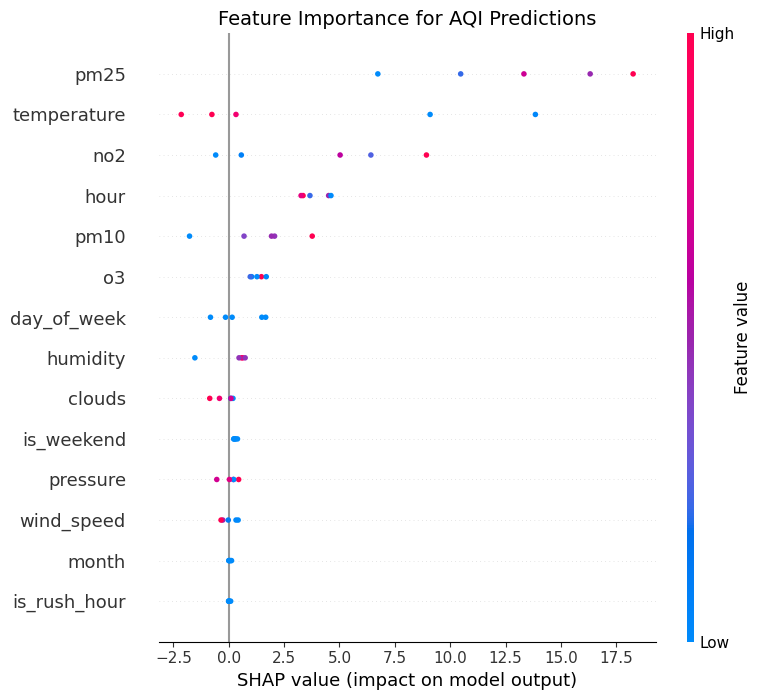


✅ SHAP analysis complete! Understanding what drives AQI predictions.


In [43]:
# Cell 11: Explain predictions with SHAP
print("📊 Calculating feature importance with SHAP...\n")

# Create explainer
explainer = shap.TreeExplainer(model)

# Get sample data for explanation
sample_data = X_test[:5]

# Calculate SHAP values
shap_values = explainer.shap_values(sample_data)

# Create summary plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample_data, feature_names=feature_columns, show=False)
plt.title("Feature Importance for AQI Predictions", fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ SHAP analysis complete! Understanding what drives AQI predictions.")

In [44]:
# Cell 12: Generate 72-hour forecast
print("🌤️ Generating 72-hour AQI forecast...\n")

# Create future timestamps
future_hours = 72
future_predictions = []
start_time = datetime.now()

for i in range(1, future_hours + 1, 3):  # Every 3 hours
    future_time = start_time + timedelta(hours=i)

    # Simulate future weather patterns
    hour_of_day = future_time.hour
    temp = 20 + 5 * np.sin(2 * np.pi * (hour_of_day - 14) / 24)
    humidity = 60 + 15 * np.sin(2 * np.pi * hour_of_day / 24)

    future_features = pd.DataFrame([{
        'temperature': temp + np.random.normal(0, 2),
        'humidity': humidity + np.random.normal(0, 5),
        'pressure': 1013,
        'wind_speed': np.random.uniform(0, 8),
        'clouds': np.random.uniform(0, 60),
        'hour': future_time.hour,
        'day_of_week': future_time.weekday(),
        'month': future_time.month,
        'is_weekend': 1 if future_time.weekday() >= 5 else 0,
        'is_rush_hour': 1 if future_time.hour in [7,8,9,17,18,19] else 0,
        'pm25': 50 + np.random.normal(0, 10),
        'pm10': 70 + np.random.normal(0, 15),
        'no2': 30 + np.random.normal(0, 5),
        'o3': 40 + np.random.normal(0, 8)
    }])

    pred = model.predict(future_features)[0]
    future_predictions.append({
        'time': future_time,
        'predicted_aqi': max(0, pred)
    })

forecast_df = pd.DataFrame(future_predictions)

# Display forecast
print("📅 3-DAY AQI FORECAST")
print("=" * 50)
print(f"{'Time':<20} {'Predicted AQI':<15} {'Status'}")
print("-" * 50)

for _, row in forecast_df.iterrows():
    aqi = row['predicted_aqi']
    if aqi <= 50: status = "🟢 Good"
    elif aqi <= 100: status = "🟡 Moderate"
    elif aqi <= 150: status = "🟠 Unhealthy for Sensitive"
    elif aqi <= 200: status = "🔴 Unhealthy"
    else: status = "⚫ Hazardous"

    print(f"{row['time'].strftime('%Y-%m-%d %H:00'):<20} {aqi:<15.1f} {status}")

print("\n" + "=" * 50)

# Alert for hazardous levels
if any(forecast_df['predicted_aqi'] > 200):
    print("🚨 🚨 🚨 HAZARDOUS AQI LEVELS PREDICTED! 🚨 🚨 🚨")
    print("Take immediate precautions: Wear N95 masks, avoid outdoor activities")
elif any(forecast_df['predicted_aqi'] > 150):
    print("⚠️ Unhealthy AQI predicted. Sensitive groups should limit outdoor exposure")

🌤️ Generating 72-hour AQI forecast...

📅 3-DAY AQI FORECAST
Time                 Predicted AQI   Status
--------------------------------------------------
2026-06-21 15:00     81.4            🟡 Moderate
2026-06-21 18:00     72.6            🟡 Moderate
2026-06-21 21:00     66.4            🟡 Moderate
2026-06-22 00:00     77.8            🟡 Moderate
2026-06-22 03:00     93.2            🟡 Moderate
2026-06-22 06:00     111.7           🟠 Unhealthy for Sensitive
2026-06-22 09:00     119.8           🟠 Unhealthy for Sensitive
2026-06-22 12:00     120.4           🟠 Unhealthy for Sensitive
2026-06-22 15:00     86.8            🟡 Moderate
2026-06-22 18:00     99.7            🟡 Moderate
2026-06-22 21:00     76.9            🟡 Moderate
2026-06-23 00:00     81.3            🟡 Moderate
2026-06-23 03:00     102.5           🟠 Unhealthy for Sensitive
2026-06-23 06:00     101.4           🟠 Unhealthy for Sensitive
2026-06-23 09:00     129.0           🟠 Unhealthy for Sensitive
2026-06-23 12:00     123.0         

In [45]:
# Install Streamlit and required packages
!pip install streamlit pyngrok -q

print("✅ Packages installed!")

✅ Packages installed!


In [46]:
# ============================================
# CREATE STREAMLIT APP FILE
# ============================================

streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Page configuration
st.set_page_config(
    page_title="Karachi AQI Predictor",
    page_icon="🇵🇰",
    layout="wide"
)

# Title
st.title("🇵🇰 Karachi Air Quality Predictor")
st.markdown("### Real-time AQI Monitoring & 3-Day Forecast")

# Sidebar
with st.sidebar:
    st.header("📍 Karachi, Pakistan")
    st.markdown(f"**Date:** {datetime.now().strftime('%d %B %Y')}")
    st.markdown(f"**Time:** {datetime.now().strftime('%I:%M %p')}")

    st.markdown("---")
    st.header("⚙️ Settings")
    forecast_days = st.slider("Forecast Days", 1, 5, 3)

    st.markdown("---")
    st.header("📊 About")
    st.info("""
    This app predicts Air Quality Index (AQI)
    for Karachi using machine learning.

    **Model:** Random Forest
    **Data:** OpenWeather API
    """)

# Generate sample data for demonstration
np.random.seed(42)

# Current conditions
current_aqi = 85
current_pm25 = 45.5
current_pm10 = 72.3
current_temp = 32.0
current_humidity = 65
current_wind = 5.5

# Generate forecast
forecast_aqi = [
    int(current_aqi + np.random.randint(-20, 30)),
    int(current_aqi + np.random.randint(-30, 40)),
    int(current_aqi + np.random.randint(-40, 50))
]
forecast_aqi = [max(10, min(500, x)) for x in forecast_aqi]

# Main metrics
st.markdown("---")
st.subheader("📍 Current Conditions")

col1, col2, col3, col4 = st.columns(4)

with col1:
    delta = forecast_aqi[0] - current_aqi
    st.metric(
        label="Current AQI",
        value=f"{current_aqi:.0f}",
        delta=f"{delta:+.0f} tomorrow",
        delta_color="inverse"
    )

with col2:
    st.metric("PM2.5", f"{current_pm25:.1f} µg/m³")

with col3:
    st.metric("Temperature", f"{current_temp:.1f}°C")

with col4:
    st.metric("Humidity", f"{current_humidity:.0f}%")

# AQI Status
st.markdown("---")
if current_aqi <= 50:
    st.success(f"✅ **Good** - Air quality is satisfactory (AQI: {current_aqi})")
elif current_aqi <= 100:
    st.info(f"ℹ️ **Moderate** - Acceptable air quality (AQI: {current_aqi})")
elif current_aqi <= 150:
    st.warning(f"⚠️ **Unhealthy for Sensitive Groups** (AQI: {current_aqi})")
elif current_aqi <= 200:
    st.error(f"🔴 **Unhealthy** - Everyone may experience health effects (AQI: {current_aqi})")
else:
    st.error(f"💀 **Hazardous** - Health emergency! (AQI: {current_aqi})")

# 3-Day Forecast
st.markdown("---")
st.subheader("🔮 3-Day AQI Forecast")

col1, col2, col3 = st.columns(3)

days = ["Day 1 (Tomorrow)", "Day 2", "Day 3"]
emojis = ["📅", "📅", "📅"]

for i, (col, day, emoji) in enumerate(zip([col1, col2, col3], days, emojis)):
    with col:
        aqi = forecast_aqi[i]

        if aqi <= 50:
            color = "🟢"
            status = "Good"
        elif aqi <= 100:
            color = "🟡"
            status = "Moderate"
        elif aqi <= 150:
            color = "🟠"
            status = "Unhealthy (Sensitive)"
        elif aqi <= 200:
            color = "🔴"
            status = "Unhealthy"
        else:
            color = "⚫"
            status = "Hazardous"

        st.markdown(f"""
        <div style="padding: 20px; border-radius: 10px; background-color: {'#1a1a1a' if aqi > 150 else '#0a2a0a'}; text-align: center;">
            <h3>{emoji} {day}</h3>
            <h1 style="font-size: 3em;">{aqi}</h1>
            <p>{color} {status}</p>
        </div>
        """, unsafe_allow_html=True)

# Trend Chart
st.markdown("---")
st.subheader("📈 72-Hour AQI Trend")

# Generate hourly trend data
hours = []
values = []
now = datetime.now()

for h in range(0, 73, 3):
    time_point = now + timedelta(hours=h)
    hours.append(time_point.strftime("%I%p %d/%m"))

    if h < 24:
        values.append(current_aqi + (forecast_aqi[0] - current_aqi) * (h/24))
    elif h < 48:
        values.append(forecast_aqi[0] + (forecast_aqi[1] - forecast_aqi[0]) * ((h-24)/24))
    else:
        values.append(forecast_aqi[1] + (forecast_aqi[2] - forecast_aqi[1]) * ((h-48)/24))

fig = go.Figure()

# Add AQI line
fig.add_trace(go.Scatter(
    x=hours,
    y=values,
    mode='lines+markers',
    name='Predicted AQI',
    line=dict(color='#00ff00', width=3),
    fill='tozeroy',
    fillcolor='rgba(0, 255, 0, 0.1)'
))

# Add threshold lines
fig.add_hline(y=50, line_dash="dash", line_color="green",
              annotation_text="Good (50)", opacity=0.5)
fig.add_hline(y=100, line_dash="dash", line_color="yellow",
              annotation_text="Moderate (100)", opacity=0.5)
fig.add_hline(y=150, line_dash="dash", line_color="orange",
              annotation_text="Unhealthy (150)", opacity=0.5)
fig.add_hline(y=200, line_dash="dash", line_color="red",
              annotation_text="Very Unhealthy (200)", opacity=0.5)

fig.update_layout(
    title="Predicted AQI Over Next 72 Hours",
    xaxis_title="Time",
    yaxis_title="AQI Value",
    height=500,
    hovermode='x unified',
    template="plotly_dark"
)

st.plotly_chart(fig, use_container_width=True)

# Pollutant Breakdown
st.markdown("---")
st.subheader("🔬 Current Pollutant Levels")

pollutants = {
    'PM2.5': current_pm25,
    'PM10': current_pm10,
    'NO2': 28.5,
    'SO2': 12.3,
    'O3': 35.7,
    'CO': 0.8
}

fig_pollutants = go.Figure(go.Bar(
    x=list(pollutants.keys()),
    y=list(pollutants.values()),
    marker_color=['#ff4444', '#ff8800', '#ffaa00', '#ffdd00', '#88ff00', '#00ff88'],
    text=[f"{v:.1f}" for v in pollutants.values()],
    textposition='auto'
))

fig_pollutants.update_layout(
    title="Pollutant Concentrations (µg/m³)",
    height=400,
    template="plotly_dark"
)

st.plotly_chart(fig_pollutants, use_container_width=True)

# Health Recommendations
st.markdown("---")
st.subheader("💡 Health Recommendations")

rec_col1, rec_col2 = st.columns(2)

with rec_col1:
    st.markdown("""
    ### If AQI is High (>150):
    - 😷 Wear N95 mask outdoors
    - 🏠 Stay indoors if possible
    - 🪟 Keep windows closed
    - 💨 Use air purifier
    - 🏃 Avoid outdoor exercise
    """)

with rec_col2:
    st.markdown("""
    ### General Tips:
    - 🌅 Exercise early morning (better air)
    - 🌿 Keep indoor plants
    - 📱 Check AQI before going out
    - 🚗 Avoid high-traffic areas
    - 💧 Stay hydrated
    """)

# Footer
st.markdown("---")
st.markdown(
    f"<center>🌊 Built for Karachi, Pakistan | Data: OpenWeather API | "
    f"Last Updated: {datetime.now().strftime('%d %B %Y, %I:%M %p')}</center>",
    unsafe_allow_html=True
)
'''

# Write the Streamlit app to a file
with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("✅ Streamlit app file created: app.py")

✅ Streamlit app file created: app.py


In [ ]:
# ============================================
# START STREAMLIT WITH PUBLIC URL
# ============================================

import subprocess
import time
from pyngrok import ngrok
import os

print("🚀 Starting Streamlit server...")

# Kill any existing Streamlit processes
import signal
try:
    subprocess.run(['pkill', '-f', 'streamlit'], check=False)
    time.sleep(2)
except:
    pass

# Start Streamlit in background
streamlit_process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait for Streamlit to start
print("⏳ Waiting for Streamlit to start...")
time.sleep(5)

# Create ngrok tunnel
print("🔗 Creating public URL...")
try:
    # Terminate any existing ngrok tunnels
    ngrok.kill()

    # Create new tunnel
    public_url = ngrok.connect(8501)
    print("\n" + "="*60)
    print("✅ STREAMLIT APP IS LIVE!")
    print("="*60)
    print(f"🔗 Public URL: {public_url}")
    print(f"📱 Open this URL in your browser")
    print("="*60)
    print("\n⚠️ Keep this cell running - do not stop it!")
    print("💡 To stop: Click the stop button (⏹️) or restart runtime")

except Exception as e:
    print(f"❌ Error creating tunnel: {e}")
    print("\nTrying alternative method...")

    # Alternative: use localhost.run
    try:
        !streamlit run app.py --server.port 8501 &
        time.sleep(5)
        !npx localtunnel --port 8501
    except:
        print("Please run: !streamlit run app.py")

🚀 Starting Streamlit server...
⏳ Waiting for Streamlit to start...
🔗 Creating public URL...


ERROR:pyngrok.process.ngrok:t=2026-06-21T14:49:32+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-21T14:49:32+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-21T14:49:32+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

❌ Error creating tunnel: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

Trying alternative method...


2026-06-21 14:49:33.330 Port 8501 is not available
⠙⠹⠸⠼⠴your url is: https://breezy-spies-wear.loca.lt


In [ ]:
# In Colab, create a zip file
import zipfile
import os

# Create all necessary files first
# ... (create files as shown above)

# Create zip
with zipfile.ZipFile('aqi_app.zip', 'w') as zipf:
    # Add all files
    for root, dirs, files in os.walk('.'):
        for file in files:
            if file not in ['aqi_app.zip']:
                zipf.write(os.path.join(root, file))

# Download the zip
from google.colab import files
files.download('aqi_app.zip')